# Name-free labels for free-vocabulary NL→FOL translations — dataset demo

This notebook is a walkthrough of the **dataset-building script** (`data.py` + the `free_group()` builder from `src/build_output.py`)
for artifact *T7b: name-free labels for R_COMP FREE rule translations*.

**Setting.** 221 templated English rules ("Each legislator who … is Emily's friend, except if …") were translated to first-order
logic by 10 LLM slots from 9 model families, with a **free vocabulary**: each model picks its own predicate names and
decompositions. That rules out exact match against a gold formula. Each candidate is labelled by an **exhaustive, name-free map search**:

* every injective map from the candidate's symbols to the template's atoms is enumerated. The map family also allows
  reification (B1/B2), merge (B3), split (B4) and lexical negation (B5);
* sound prunes (relevance, polarity, and a 128-model finite **countermodel** fingerprint) discard maps; z3 proves equivalence for any map that survives;
* **`ERROR_CERT`**: *no* map in the family makes the candidate equivalent to the template reading. This label is final and backed by certificates;
* **`UNRESOLVED_GLOSS_NOT_RUN`** (search level: `MAPPED`): some map makes it z3-equivalent. A gloss check ("does `Attends(x, boardGameNight)`
  really mean *x is at Board Game night*?") still has to accept that map. That check did not run because the OpenRouter budget ran out (deviation D9);
* `UNPARSEABLE` / `NO_OUTPUT`: coverage rows. They are counted and reported, never dropped.

The full dataset has 2,652 FREE rows. This demo loads **100 raw label rows** (stratified by label × model family × clause type)
together with the seal and testability records that `data.py` reads, and then runs the original assembly code on them
(the name-free search itself is `src/freelab.py`; its results are the inputs here).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (original data.py dependency)
_pip('loguru==0.7.3')

# pandas, matplotlib — pre-installed on Colab, install locally only (used by the summary / visualization cells)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports and logging
These are the original `data.py` imports and loguru setup. `ROOT` was `Path(__file__).parent`; in a notebook it is the current directory.
The `sys.path` inserts for `src/` and `vendor/` are gone because the one builder we need (`free_group`) is inlined below.

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

ROOT = Path(".").resolve()  # was: Path(__file__).resolve().parent

from loguru import logger  # noqa: E402

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

# extra imports for the summary / visualization cells
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
Loads `mini_demo_data.json` from GitHub, with a fallback to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/main/round-4/dataset-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("raw FREE label rows available:", len(data["free_labels_rows"]))

Demo subset for art_Ia_FT284H33j: 100 raw FREE label rows (results/free_labels_v2.jsonl; per label a fixed quota 34/34/16/16, round-robin over model families then clause types, seed 0) + the seal record and the testability summary (strata dropped) that data.py reads. Source counts are for the full 2,652-row dataset.
raw FREE label rows available: 100


## Config
`data.py` has no numeric hyper-parameters: it assembles labels that have already been computed. The one knob is how many raw label rows to assemble.
The original run uses all 2,652 rows from `results/free_labels_v2.jsonl`. This demo file holds 100 of them.
`SELECTED` is the original list of output groups.

In [5]:
N_ROWS = 100          # raw FREE label rows to assemble (demo file holds 100; original full run: 2652)
SELECTED = ["rcomp_free_labels", "gloss_gate_items", "sig_soundness_replay"]  # original data.py value

## Row builder: `free_group()` (from `src/build_output.py`)
Each raw label row becomes one `exp_sel_data_out` example:
* `input` is a JSON string holding the sentence, the candidate FOL and which system produced it (slot, family, prompt variant);
* `output` is the name-free label (`ERROR_CERT`, `UNRESOLVED_GLOSS_NOT_RUN`, `UNPARSEABLE` or `NO_OUTPUT`);
* the `metadata_*` fields carry the strata (template, clause type, word tercile, …), the **map certificate** (which candidate symbol maps to which
  template atom, and which bridges were used), the counts of non-equivalence certificates, and the `gloss_pairs` that the checker will judge.

`label_binary_search_provisional` collapses the label to `ERROR` / `MAPPED` / `EXCLUDED`. That provisional binary view is the one that is currently
testable, because no `CORRECT` class exists until the gloss step runs.

The only change from the original is the first line: rows come from the loaded `data` instead of `load_jsonl(RES / "free_labels_v2.jsonl")`.

In [6]:
def md(d: dict) -> dict:
    return {f"metadata_{k}": v for k, v in d.items()}


def free_group() -> dict:
    rows = data["free_labels_rows"][:N_ROWS]  # was: load_jsonl(RES / "free_labels_v2.jsonl")
    ex = []
    for r in rows:
        inp = {"text": r["text"], "candidate_fol": r["candidate_fol"], "system": r["system"], "family": r["family"],
               "slot": r["slot"], "prompt_variant": r["prompt_variant"], "condition": "FREE", "template_id": r["template_id"]}
        search_bin = {"ERROR_CERT": "ERROR", "UNRESOLVED_GLOSS_NOT_RUN": "MAPPED"}.get(r["label"], "EXCLUDED")
        meta = {
            "row_key": r["row_key"], "item_id": r["item_id"], "sentence_id": r["sentence_id"], "template_id": r["template_id"],
            "clause_type": r["clause_type"], "words": r["words"], "word_tercile": r["word_tercile"],
            "nconds_weak": r["nconds_weak"], "negated_condition": r["negated_condition"], "nested": r["nested"],
            "label_binary": r["label_binary"], "label_binary_search_provisional": search_bin,
            "label_source": r["label_source"], "search_status": r.get("search_status"),
            "matched_reading": r.get("matched_reading") or r.get("matched_reading_search"),
            "map_certificate": r.get("map_certificate"),
            "n_maps_enumerated": r.get("n_maps_enumerated"), "n_maps_fingerprint_pass": r.get("n_maps_fingerprint_pass"),
            "n_equiv_maps": r.get("n_equiv_maps"), "n_equiv_map_orbits": r.get("n_equiv_map_orbits"),
            "nonequiv_certificate_type_counts": r.get("nonequiv_certificate_type_counts"),
            "gloss_pairs": r.get("gloss_pairs"), "gloss_decision": r.get("gloss_decision"),
            "unresolved_reason": r.get("unresolved_reason"), "irrelevant_symbols": r.get("irrelevant_symbols"),
            "search_secs": r.get("search_secs"), "seen_iter3": r.get("seen_iter3"),
            "old_label_iter3": r.get("old_label_iter3"), "fold": "RCOMP_FREE"}
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": r["label"], **md(meta)})
    return {"dataset": "rcomp_free_labels", "examples": ex}

### The other two groups (reference only, not run here)
The full `full_data_out.json` also has `gloss_gate_items`: 840 known-answer (symbol use, meaning) items used to validate the gloss checker.
It also has `sig_soundness_replay`: 4,280 renamed SIG rows with known pure-z3 labels, used to test the search's soundness under renaming.
Their builders are below, unchanged from `src/build_output.py`. They read run-local files (`results/gate_items.json`, `results/sig_replay_rows.jsonl`,
`work/sentences.json`), and the demo file (one dataset only) does not include those, so the builders are defined here but never called.

In [7]:
RES, WORK = ROOT / "results", ROOT / "work"  # original paths (src/common.py); not present in the demo


def load_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()]


def gate_group() -> dict:
    items = json.loads((RES / "gate_items.json").read_text())
    ex = []
    for i in items:
        inp = {"sentence": i["sentence"], "candidate_atom": i["candidate_atom"], "proposed_meaning": i["proposed_meaning"]}
        meta = {"item_id": i["item_id"], "class": i["class"], "half": i["half"], "sentence_id": i["sentence_id"],
                "template_id": i["template_id"], "note": i["note"], "prompt_version": "gloss_v1",
                "haiku_verdict": i.get("haiku_gloss_v1"), "qwen_verdict": i.get("qwen_gloss_v1"), "fold": "GLOSS_GATE"}
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": i["gold"], **md(meta)})
    return {"dataset": "gloss_gate_items", "examples": ex}


def sig_group() -> dict:
    sents = json.loads((WORK / "sentences.json").read_text())
    rows = load_jsonl(RES / "sig_replay_rows.jsonl")
    ex = []
    for r in rows:
        inp = {"text": sents[r["sentence_id"]]["text"], "candidate_fol": r["renamed_fol"], "rename": r["rename"],
               "template_id": r["template_id"]}
        meta = {k: r[k] for k in ("row_key", "sentence_id", "slot", "template_id", "sig_matched_reading", "canon_fol",
                                  "search_status", "identity_map_found", "non_identity_map_found", "n_equiv_maps",
                                  "n_equiv_map_orbits", "n_maps_enumerated", "nonequiv_certificate_type_counts",
                                  "oracle_end_to_end_label", "in_e2e_gloss_subsample_300", "e2e_gloss_label")}
        meta["map_equiv_found"] = r["search_status"] in ("MAPPED", "READING_CHOICE")
        meta["fold"] = f"SIG_REPLAY_{r['rename'].upper()}"
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": r["sig_label"], **md(meta)})
    return {"dataset": "sig_soundness_replay", "examples": ex}

## `main()` from `data.py`: assemble, validate, attach seal and testability
The original steps: build the groups; check the schema (string `input`/`output`, no reserved keys); read the last **seal** (sha256 of the label vector,
pre-registration hash) and the **testability** summary; write `full_data_out.json`.

Demo changes:
* `groups` holds only `free_group()`, the one group in the demo file (the original line is kept as a comment);
* `seal` and `t` come from `data` instead of `results/seal.json` and `results/testability_FREE_v2.json`. Their values describe the **full** 2,652-row dataset;
* the output file is named `demo_full_data_out.json` so it cannot be confused with the real artifact.

In [8]:
@logger.catch(reraise=True)
def main() -> None:
    # groups = [B.free_group(), B.gate_group(), B.sig_group()]   # original (needs run-local files)
    groups = [free_group()]
    for g in groups:
        assert g["examples"], g["dataset"]
        for e in g["examples"]:
            assert isinstance(e["input"], str) and isinstance(e["output"], str), g["dataset"]
            assert not ({"split", "dataset", "context"} & set(e)), g["dataset"]
    seal = data["seal"]["seals"][-1]          # was: json.loads((ROOT / "results" / "seal.json").read_text())["seals"][-1]
    t = data["testability_FREE_v2"]           # was: json.loads((ROOT / "results" / "testability_FREE_v2.json").read_text())
    out = {"metadata": {
        "artifact": "T7b name-free labels for free-vocabulary rule translations (run_u75jRHUss0zo, iter 4, gen_art_dataset_5)",
        "workspace": str(ROOT),
        "selection": ("the three plan groups (chosen as best 3 of 6 standardised candidates; folio / malls_test / "
                      "logicnli_test were context only: no multi-system candidates, ~36-39% wrong gold, or no FOL; their "
                      "standardised record is temp/candidates_data_out.json)"),
        "label_mode": seal["mode"],
        "status_note": ("SEARCH-ONLY labels: the paid gloss step could not run (deviation D9: run OpenRouter budget "
                        "exhausted before this artifact's first call; re-probed at packaging, still HTTP 403). ERROR_CERT is "
                        "final and certificate-backed; MAPPED rows are UNRESOLVED_GLOSS_NOT_RUN until src/resume_gloss.py "
                        "runs. metadata_label_binary_search_provisional (ERROR vs MAPPED) is a provisional view with audited "
                        "contamination (results/soundness_audit.json)."),
        "seal_all_rows_sha256": seal["label_vector_sha256_all_rows"],
        "seal_untouched_sha256": seal.get("label_vector_sha256_untouched"),
        "prereg_sha256": seal["prereg_sha256"],
        "testability_all_rows": {k: t["all_rows"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "testability_untouched": {k: t["untouched_subset"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "provisional_view_testable": {k: t["search_provisional_view"][k]["TESTABLE"] for k in ("all_rows", "untouched_subset")},
    }, "datasets": [g for g in groups if g["dataset"] in SELECTED]}
    (ROOT / "demo_full_data_out.json").write_text(json.dumps(out, ensure_ascii=False))  # was: full_data_out.json
    logger.info(f"demo_full_data_out.json: {[(g['dataset'], len(g['examples'])) for g in out['datasets']]}")
    return out  # (added) keep the result for the summary cells


out = main()

19:49:47|INFO   |demo_full_data_out.json: [('rcomp_free_labels', 100)]


## Results: what the labels look like
First, the dataset-level metadata from the seal and testability summary. These numbers describe the **full** 2,652 rows, not the demo subset.
With search-only labels there is no `CORRECT` class yet, so AUROC is NOT_TESTABLE. The provisional ERROR_CERT-vs-MAPPED view *is* testable.

In [9]:
m = out["metadata"]
print("label_mode:", m["label_mode"])
print("seal (all rows):  ", m["seal_all_rows_sha256"][:16], "...")
print("seal (untouched): ", (m["seal_untouched_sha256"] or "")[:16], "...")
print("prereg sha256:    ", m["prereg_sha256"][:16], "...")
full_tab = pd.DataFrame({
    "all rows (2,652)": m["testability_all_rows"]["label_counts"],
    "untouched (2,198, primary)": m["testability_untouched"]["label_counts"],
}).fillna(0).astype(int)
print("\nFULL-dataset label counts:\n", full_tab.to_string())
print("\nTESTABLE (ERROR vs CORRECT):", m["testability_all_rows"]["TESTABLE"],
      "| provisional ERROR_CERT vs MAPPED view TESTABLE:", m["provisional_view_testable"])

label_mode: search_only
seal (all rows):   9609ebbb725832c4 ...
seal (untouched):  b364a49a8e21835d ...
prereg sha256:     b081c39991f52da2 ...

FULL-dataset label counts:
                           all rows (2,652)  untouched (2,198, primary)
ERROR_CERT                             759                         636
UNRESOLVED_GLOSS_NOT_RUN              1506                        1175
UNPARSEABLE                            188                         188
NO_OUTPUT                              199                         199

TESTABLE (ERROR vs CORRECT): False | provisional ERROR_CERT vs MAPPED view TESTABLE: {'all_rows': True, 'untouched_subset': True}


Next, the assembled demo rows: labels by model family and by clause type, plus two example rows with their certificates.

In [10]:
ex = out["datasets"][0]["examples"]
df = pd.DataFrame([{**json.loads(e["input"]), "label": e["output"],
                    **{k[9:]: v for k, v in e.items() if k.startswith("metadata_")}} for e in ex])
print(f"{len(df)} assembled rows | label counts: {dict(Counter(df['label']))}")
print("\nlabel x family:\n", pd.crosstab(df["family"], df["label"]).to_string())
print("\nsearch-provisional binary x clause type:\n",
      pd.crosstab(df["clause_type"], df["label_binary_search_provisional"]).to_string())

for lab in ("ERROR_CERT", "UNRESOLVED_GLOSS_NOT_RUN"):
    sub = df[df["label"] == lab]
    if len(sub) == 0:
        continue
    r = sub.iloc[0]
    print(f"\n=== example {lab} ({r['system']}) ===")
    print("TEXT:", r["text"])
    print("FOL: ", r["candidate_fol"])
    print("maps enumerated:", int(r["n_maps_enumerated"]), "| equivalent maps:", int(r["n_equiv_maps"]),
          "| non-equiv certificates:", r["nonequiv_certificate_type_counts"])
    if r["map_certificate"]:
        print("map certificate (reading =", r["map_certificate"]["reading"], ", bridges =", r["map_certificate"]["bridges"], "):")
        for mline in r["map_certificate"]["map"]:
            print("   ", mline)
        print(f"gloss pairs pending check ({len(r['gloss_pairs'])}, first 6 shown):", [(g["cand_atom"], g["meaning"]) for g in r["gloss_pairs"][:6]])

100 assembled rows | label counts: {'ERROR_CERT': 34, 'UNRESOLVED_GLOSS_NOT_RUN': 34, 'UNPARSEABLE': 16, 'NO_OUTPUT': 16}



label x family:
 label          ERROR_CERT  NO_OUTPUT  UNPARSEABLE  UNRESOLVED_GLOSS_NOT_RUN
family                                                                     
cohere                  4          0            2                         4
deepseek                4          0            2                         4
google-gemini           4          0            2                         4
google-gemma            4          0            2                         4
meta                    4          2            2                         4
microsoft               4          0            2                         4
mistral                 4          0            2                         4
openai                  3          0            1                         3
qwen                    3         14            1                         3

search-provisional binary x clause type:
 label_binary_search_provisional  ERROR  EXCLUDED  MAPPED
clause_type                                   

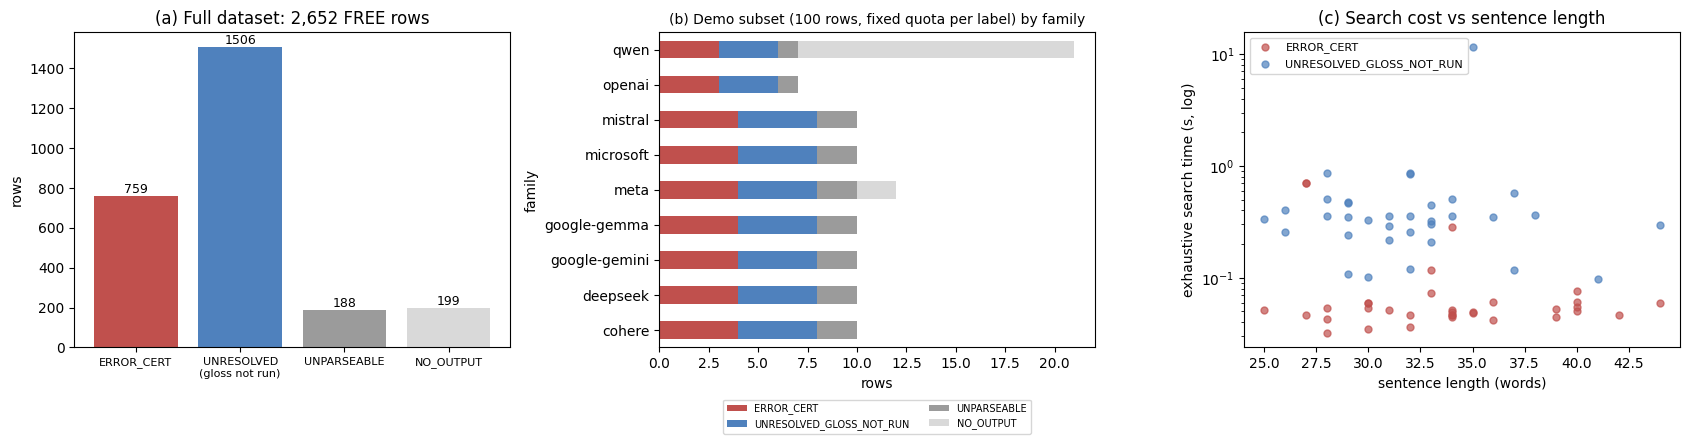

In [11]:
order = ["ERROR_CERT", "UNRESOLVED_GLOSS_NOT_RUN", "UNPARSEABLE", "NO_OUTPUT"]
colors = ["#c0504d", "#4f81bd", "#9b9b9b", "#d9d9d9"]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) full-dataset label distribution (from the seal) vs demo subset
full = m["testability_all_rows"]["label_counts"]
short = ["ERROR_CERT", "UNRESOLVED\n(gloss not run)", "UNPARSEABLE", "NO_OUTPUT"]
ax[0].bar(short, [full.get(k, 0) for k in order], color=colors)
for i, k in enumerate(order):
    ax[0].text(i, full.get(k, 0), str(full.get(k, 0)), ha="center", va="bottom", fontsize=9)
ax[0].set_title("(a) Full dataset: 2,652 FREE rows")
ax[0].set_ylabel("rows")
ax[0].tick_params(axis="x", labelsize=8)

# (b) provisional ERROR/MAPPED share per model family in the demo subset
ct = pd.crosstab(df["family"], df["label"]).reindex(columns=order, fill_value=0)
ct.plot(kind="barh", stacked=True, color=colors, ax=ax[1], legend=False)
ax[1].set_title(f"(b) Demo subset ({len(df)} rows, fixed quota per label) by family", fontsize=10)
ax[1].set_xlabel("rows")
ax[1].legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

# (c) search effort: maps enumerated vs label (parseable rows only)
p = df[df["label"].isin(order[:2])]
for lab, c in zip(order[:2], colors[:2]):
    s = p[p["label"] == lab]
    ax[2].scatter(s["words"], s["search_secs"], label=lab, color=c, alpha=0.7, s=25)
ax[2].set_yscale("log")
ax[2].set_xlabel("sentence length (words)")
ax[2].set_ylabel("exhaustive search time (s, log)")
ax[2].set_title("(c) Search cost vs sentence length")
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

**How to read this.**
* `ERROR_CERT` rows are final. No map in the declared family (injective maps plus the B1–B5 bridges) makes the candidate z3-equivalent to any
  template reading, and every rejected map has a certificate: a pruned subtree, a polarity conflict, or a finite countermodel. The executor audit
  gives ERROR_CERT a precision of 0.867. Its misses are faithful forms outside the family, such as a disjunctive split or ∃-for-constant.
* `UNRESOLVED_GLOSS_NOT_RUN` rows *can* be made equivalent. Whether the winning map is lexically plausible is decided by the pending gloss
  check (`src/resume_gloss.py`), which turns these rows into CORRECT or ERROR. In the SIG replay, non-identity maps rescued 9–10% of known-ERROR rows,
  and those are the cases the gloss check must stop.
* Panel (b) shows a quota sample (34/34/16/16 rows per label), so its per-family label shares are not the population rates. In the full data,
  197 of the 199 NO_OUTPUT rows come from the qwen slot.
* Search is cheap: fractions of a second per candidate. The gloss check is the only paid step (~$1.8 for the whole audit).